# Model Interpretation

Коротко: разбираем лучшую модель: важность признаков, SHAP, ошибки, ROC и итоговые метрики.


## Setup / Настройка


In [1]:
# База / core
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap

# Sklearn / ML
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Корень проекта / project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

# Стиль / style
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)


## Data / Данные


In [2]:
# Данные после FE / data after feature engineering
df_model = pd.read_parquet(ROOT / "data" / "titanic_fe.parquet")

X = df_model.drop(columns="survived")
y = df_model["survived"].astype(int)


## Split & Model / Split и модель


In [3]:
# Split как раньше / same split as before
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


In [4]:
# Лучшая модель / best model
best_model = joblib.load(ROOT / "models" / "best_model.pkl")


In [5]:
# Предсказания / predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


## Feature Importance / Важность признаков


In [6]:
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_model
    .named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances
        }
    )
    .sort_values(
        by="importance",
        ascending=False
    )
)

display(importance_df.head(20))

,feature,importance
14,cat__sex_male,0.107783
24,cat__Title_Mr,0.100140
13,cat__sex_female,0.098270
49,cat__SexPclass_female_1,0.050559
4,num__fare,0.041790
7,num__FarePerPerson,0.039906
8,num__FemaleWithChildren,0.034318
54,cat__SexPclass_male_3,0.032687
25,cat__Title_Mrs,0.032084
0,num__pclass,0.028571


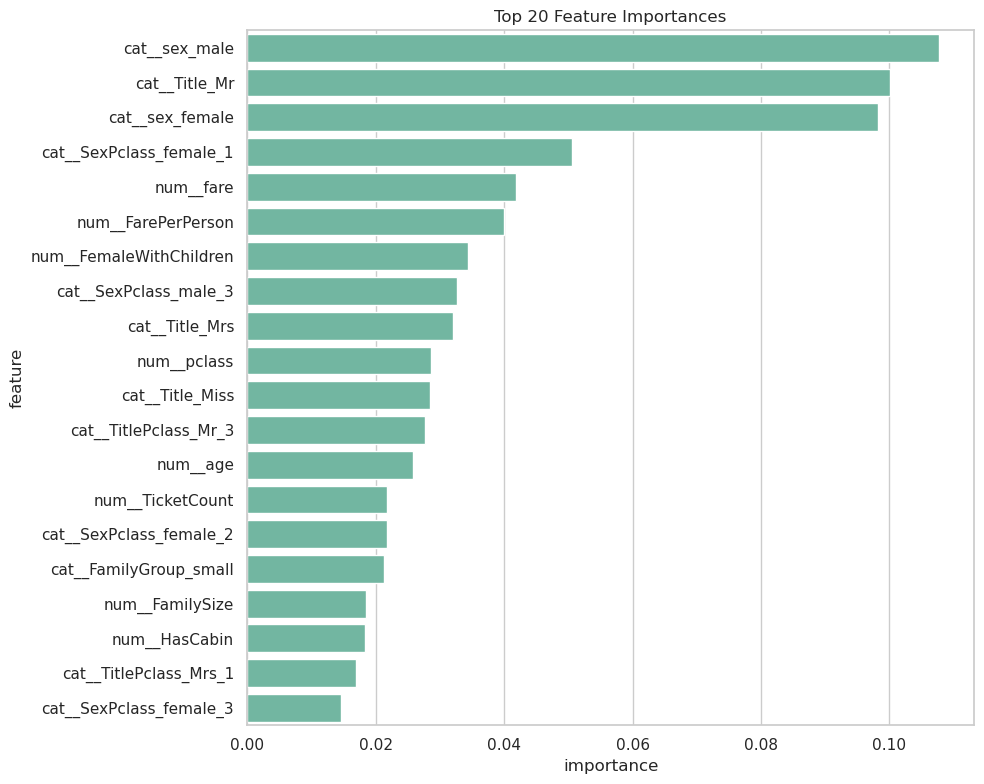

In [7]:
# Top-20 признаков / feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


## SHAP / Интерпретация


In [8]:
X_test_transformed = (
    best_model
    .named_steps["preprocessor"]
    .transform(X_test)
)

In [9]:
# SHAP для класса 1 / SHAP for class 1
explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)

# Старый и новый SHAP API / old and new SHAP API
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]


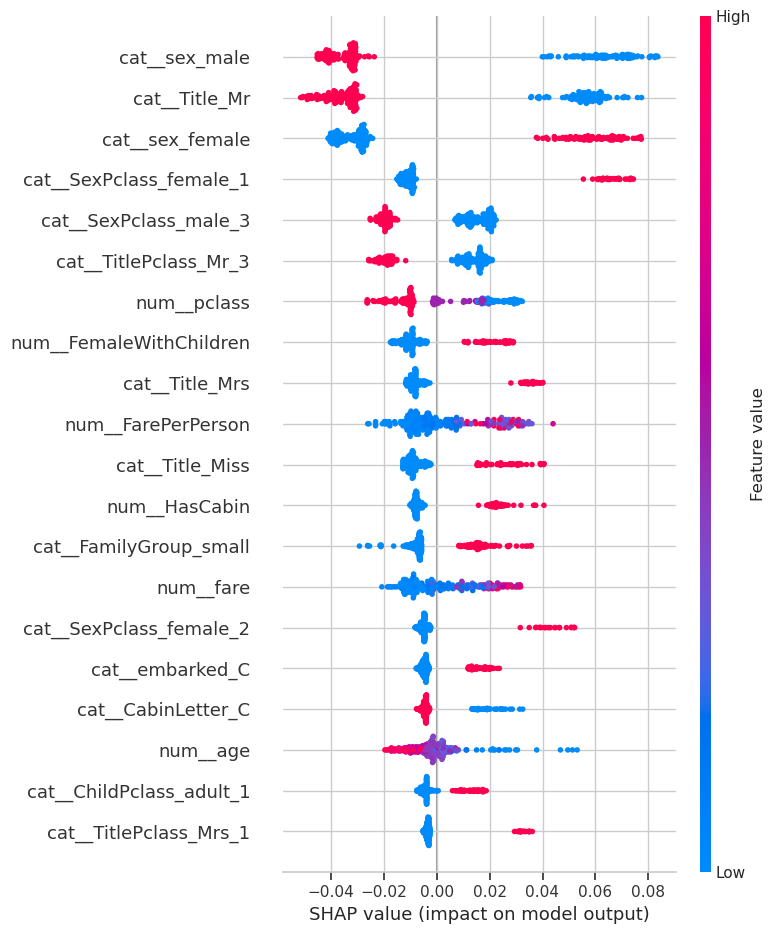

In [10]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

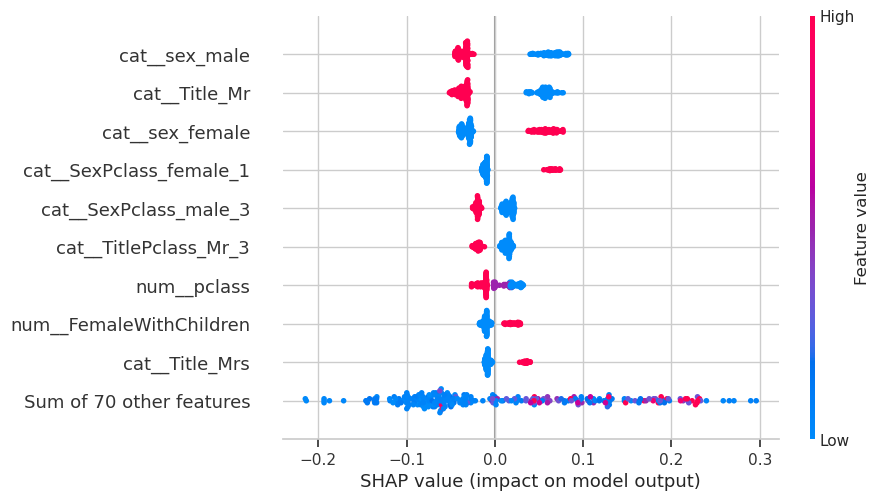

In [11]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        data=X_test_transformed,
        feature_names=feature_names
    )
)

## Metrics / Метрики


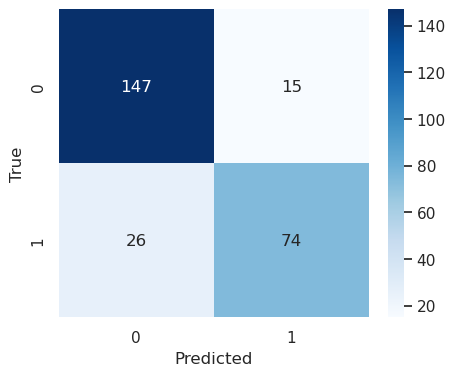

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       162
           1       0.83      0.74      0.78       100

    accuracy                           0.84       262
   macro avg       0.84      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262



In [14]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

auc = roc_auc_score(
    y_test,
    y_proba
)

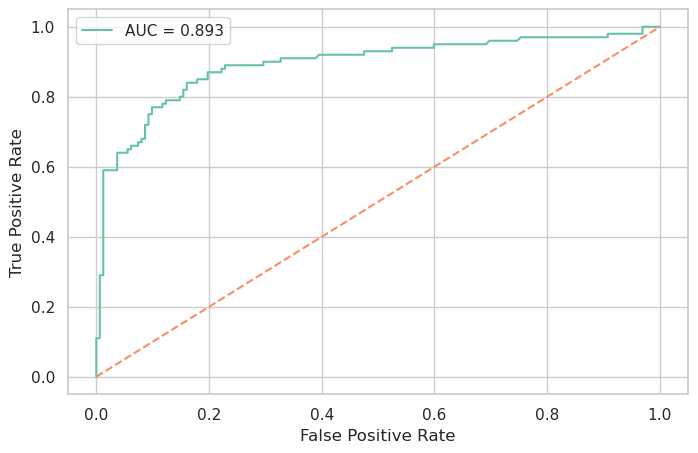

In [15]:
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate") 
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [16]:
accuracy = (
    y_pred == y_test
).mean()

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8435


## Error Analysis / Ошибки


In [17]:
false_positive = X_test[
    (y_test == 0)
    &
    (y_pred == 1)
]

print(false_positive.shape)

display(
    false_positive.head()
)

(15, 23)


,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,FamilyGroup,FarePerPerson,FemaleWithChildren,Title,TicketCount,SharedTicket,TicketPrefix,HasCabin,CabinLetter,AgeGroup,Child,SexPclass,TitlePclass,ChildPclass
975,3,female,26.0,1,0,16.1000,S,2,0,small,8.050000,1,Mrs,2,1,A,0,NaN,young,0.0,female_3,Mrs_3,adult_3
1263,3,male,11.5,1,1,14.5000,S,3,0,small,4.833333,0,Master,3,1,A,0,NaN,child,1.0,male_3,Master_3,child_3
1153,3,female,47.0,1,0,14.5000,S,2,0,small,7.250000,1,Mrs,2,1,A,0,NaN,adult,0.0,female_3,Mrs_3,adult_3
650,3,female,17.0,0,0,14.4583,C,1,1,single,14.458300,0,Miss,2,1,NONE,0,NaN,young,0.0,female_3,Miss_3,adult_3
749,3,female,28.0,1,1,14.4000,S,3,0,small,4.800000,1,Mrs,3,1,NONE,0,NaN,young,0.0,female_3,Mrs_3,adult_3


In [18]:
false_negative = X_test[
    (y_test == 1)
    &
    (y_pred == 0)
]

print(false_negative.shape)

display(
    false_negative.head()
)

(26, 23)


,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,FamilyGroup,FarePerPerson,FemaleWithChildren,Title,TicketCount,SharedTicket,TicketPrefix,HasCabin,CabinLetter,AgeGroup,Child,SexPclass,TitlePclass,ChildPclass
1121,3,male,NaN,1,1,22.3583,C,3,0,small,7.452767,0,Master,3,1,NONE,0,NaN,NaN,NaN,male_3,Master_3,unknown_3
20,1,male,37.0,1,1,52.5542,S,3,0,small,17.518067,0,Mr,2,1,NONE,1,D,adult,0.0,male_1,Mr_1,adult_1
183,1,male,35.0,0,0,512.3292,C,1,1,single,512.329200,0,Mr,4,1,PC,1,B,adult,0.0,male_1,Mr_1,adult_1
742,3,male,45.0,0,0,8.0500,S,1,1,single,8.050000,0,Mr,1,0,NONE,0,NaN,adult,0.0,male_3,Mr_3,adult_3
889,3,male,26.0,0,0,7.7750,S,1,1,single,7.775000,0,Mr,1,0,NONE,0,NaN,young,0.0,male_3,Mr_3,adult_3


In [19]:
errors = X_test.copy()

errors["y_true"] = y_test.values
errors["y_pred"] = y_pred
errors["correct"] = (
    errors["y_true"]
    ==
    errors["y_pred"]
)

display(
    errors.head()
)

,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,FamilyGroup,FarePerPerson,FemaleWithChildren,Title,TicketCount,SharedTicket,TicketPrefix,HasCabin,CabinLetter,AgeGroup,Child,SexPclass,TitlePclass,ChildPclass,y_true,y_pred,correct
1028,3,female,NaN,1,0,24.1500,Q,2,0,small,12.075000,1,Miss,3,1,NONE,0,NaN,NaN,NaN,female_3,Miss_3,unknown_3,1,1,True
1121,3,male,NaN,1,1,22.3583,C,3,0,small,7.452767,0,Master,3,1,NONE,0,NaN,NaN,NaN,male_3,Master_3,unknown_3,1,0,False
1155,3,male,NaN,0,0,7.7750,S,1,1,single,7.775000,0,Mr,1,0,NONE,0,NaN,NaN,NaN,male_3,Mr_3,unknown_3,0,0,True
1251,3,male,30.5,0,0,8.0500,S,1,1,single,8.050000,0,Mr,1,0,NONE,0,NaN,adult,0.0,male_3,Mr_3,adult_3,0,0,True
721,3,male,36.0,0,0,7.4958,S,1,1,single,7.495800,0,Mr,1,0,NONE,0,NaN,adult,0.0,male_3,Mr_3,adult_3,0,0,True


## Входы, выходы и выводы / Inputs, outputs & conclusions

- Вход: `data/titanic_fe.parquet` и `models/best_model.pkl`.
- Выход: важность признаков, SHAP-графики, confusion matrix, classification report, ROC-AUC и разбор ошибок.
- Вывод: интерпретация показывает, какие признаки сильнее всего двигают прогноз, а ошибки помогают понять слабые места модели перед финальной защитой.
